## 1. Library Imports (라이브러리 임포트)


This section imports the required libraries for audio-based emotion recognition.  
- os: Handles file paths and directory operations.  
- numpy: Used for numerical operations and array manipulations.  
- librosa: A key library for audio signal processing (e.g., loading, transforming, extracting features).  
- sklearn.preprocessing.StandardScaler: Used to normalize or standardize the extracted audio features.  
---
이 섹션은 오디오 기반 감정 인식에 필요한 라이브러리들을 불러옵니다.  
- os: 파일 경로 및 디렉터리 작업을 처리합니다.  
- numpy: 수치 계산 및 배열 연산에 사용됩니다.  
- librosa: 오디오 신호 처리(예: 로드, 변환, 특징 추출)에 사용되는 핵심 라이브러리입니다.  
- sklearn.preprocessing.StandardScaler: 추출된 오디오 특징을 정규화(표준화)할 때 사용됩니다.


In [5]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler

## 2. Dataset Construction (데이터셋 구성 – TESS + RAVDESS + 감정 필터링)
  
This section constructs the audio emotion dataset by combining **TESS** and **RAVDESS**, two widely used emotional speech corpora.  
It filters and extracts only the selected emotions: *angry*, *happy*, *neutral*, and *sad*.  
Each audio file is converted into a 100-dimensional MFCC (Mel-Frequency Cepstral Coefficient) vector, which represents key audio features for emotion recognition.

Steps:
- Define dataset paths (`TESS_path`, `RAVDESS_path`)
- Specify target emotions and map them to numerical labels (`emotion_map`)
- Iterate through both datasets and extract `.wav` files containing target emotion keywords
- Load each audio file using `librosa.load`
- Compute 100-dimensional MFCC features and take their mean across time
- Store the features and corresponding emotion labels into lists (`speech_data`, `speech_labels`)

---
이 섹션은 **TESS**와 **RAVDESS** 두 감정 음성 데이터셋을 결합하여 오디오 감정 데이터셋을 구성합니다.  
선택된 감정(*angry*, *happy*, *neutral*, *sad*)만 필터링하여 사용합니다.  
각 오디오 파일은 감정 인식에 유용한 100차원 MFCC(Mel-Frequency Cepstral Coefficient) 벡터로 변환됩니다.

단계:
- 데이터셋 경로를 설정합니다 (`TESS_path`, `RAVDESS_path`)  
- 사용할 감정을 정의하고, 각 감정을 숫자 라벨로 매핑합니다 (`emotion_map`)  
- 두 데이터셋의 폴더를 순회하며 감정 이름이 포함된 `.wav` 파일을 탐색합니다  
- `librosa.load`로 오디오를 로드합니다  
- 100차원 MFCC 특징을 추출하고 시간축 평균을 계산합니다  
- 추출된 특징과 감정 라벨을 리스트(`speech_data`, `speech_labels`)에 저장합니다


In [ ]:
# 데이터셋 구성 - TESS + RAVDESS + 감정 필터링

import os
import librosa
import numpy as np

# 경로 설정
TESS_path = r'C:\Users\a\kimleepark\TESS Toronto emotional speech set data'
RAVDESS_path = r'C:\Users\a\kimleepark\Ravdess_by_emotion'

# 사용할 감정
selected_emotions = ['angry', 'happy', 'neutral', 'sad']
emotion_map = {emotion: idx for idx, emotion in enumerate(selected_emotions)}

# 데이터 저장 리스트
speech_data = []
speech_labels = []

# 데이터 로딩
for base_path in [TESS_path, RAVDESS_path]:
    for folder in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder)

        # 감정이 폴더 이름에 포함되어 있는지 확인
        for emotion in selected_emotions:
            if emotion in folder.lower():
                for file in os.listdir(folder_path):
                    if file.endswith('.wav'):
                        # 오디오 로딩
                        y, sr = librosa.load(os.path.join(folder_path, file), sr=None)
                        # MFCC 100차원 추출
                        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=100)
                        mfcc_scaled = np.mean(mfcc.T, axis=0)
                        speech_data.append(mfcc_scaled)
                        speech_labels.append(emotion_map[emotion])
                break  # 중복 방지


## 3. Data Distribution Check (데이터 분포 확인)


This part checks how many samples exist for each emotion category after dataset construction.  
It helps verify dataset balance and ensure that all selected emotions are properly loaded.

Steps:
- Reverse the emotion mapping dictionary (`emotion_map`) to get readable emotion names (`label_names`)
- Use `collections.Counter` to count how many samples belong to each emotion
- Print the number of samples per emotion in a formatted output

---
이 부분은 데이터셋 구성 이후 각 감정별 샘플 개수를 확인하는 단계입니다.  
데이터의 불균형 여부를 파악하고, 선택한 모든 감정이 올바르게 로드되었는지 검증할 수 있습니다.

단계:
- 감정 인덱스를 다시 감정 이름으로 매핑하기 위해 `emotion_map`을 반전시켜 `label_names` 생성  
- `collections.Counter`를 사용해 각 감정별 샘플 개수를 계산  
- 감정 이름과 함께 각 샘플 수를 포맷에 맞게 출력


In [9]:
from collections import Counter

# 숫자 인덱스를 감정 이름으로 다시 매핑
label_names = {v: k for k, v in emotion_map.items()}

# 각 감정별 샘플 수 계산
label_counts = Counter(speech_labels)

# 결과 출력
for label_idx in sorted(label_counts):
    emotion = label_names[label_idx]
    count = label_counts[label_idx]
    print(f"{emotion:>7} : {count}개")


  angry : 592개
  happy : 592개
neutral : 496개
    sad : 592개


## 4. Data Normalization and Reshaping (데이터 정규화 및 차원 변환)


This section standardizes and reshapes the extracted MFCC features to prepare them for deep learning input.  
Normalization ensures that all features have zero mean and unit variance, improving model convergence.  
The data is then reshaped to match the input format of a 1D convolutional neural network (Conv1D).

Steps:
- Initialize `StandardScaler` and fit it to the feature data (`speech_data`)
- Apply scaling to normalize all MFCC values
- Expand the data dimensions to `(num_samples, 100, 1)` for Conv1D compatibility
- Convert emotion labels into a NumPy array (`y`)

--- 
이 섹션은 추출된 MFCC 특징을 정규화하고, 딥러닝 입력 형식에 맞게 변환하는 과정입니다.  
정규화를 통해 모든 특징이 평균 0, 분산 1의 분포를 가지도록 하여 모델 학습의 안정성을 높입니다.  
이후 Conv1D 신경망 입력 형태에 맞게 데이터를 재구성합니다.

단계:
- `StandardScaler`를 초기화하고, 특징 데이터(`speech_data`)에 학습시킵니다  
- 스케일링을 적용하여 모든 MFCC 값을 정규화합니다  
- Conv1D 입력 형식에 맞게 데이터 차원을 `(샘플 수, 100, 1)`로 확장합니다  
- 감정 라벨을 NumPy 배열(`y`)로 변환합니다


In [ ]:
# 데이터 정규화 및 차원 변환

from sklearn.preprocessing import StandardScaler
import numpy as np

# 스케일러 정의 및 학습
scaler = StandardScaler()
speech_data_scaled = scaler.fit_transform(speech_data)

# Conv1D 입력 형식에 맞게 마지막 축 추가 → (샘플 수, 100, 1)
X = np.expand_dims(speech_data_scaled, axis=-1)

# 라벨을 넘파이 배열로 변환
y = np.array(speech_labels)

## 5. Conv1D-based CNN Model Construction (Conv1D 기반 CNN 모델 구성)


This section builds a **1D Convolutional Neural Network (CNN)** designed for audio emotion recognition using MFCC features.  
The Conv1D architecture captures temporal audio patterns across the MFCC feature sequence.

Model Architecture:
- **Conv1D (64 filters, kernel size=5)**: extracts temporal features from 100-dimensional MFCC input  
- **MaxPooling1D (pool size=2)**: reduces sequence length while retaining key features  
- **Flatten**: converts 2D feature maps into a 1D vector  
- **Dense (64 units, ReLU)**: learns high-level emotion representations  
- **Dropout (0.3)**: prevents overfitting  
- **Dense (softmax)**: outputs class probabilities for the four emotion categories  

Compilation:
- **Optimizer:** Adam  
- **Loss:** Sparse Categorical Cross-Entropy  
- **Metrics:** Accuracy  

--- 
이 섹션에서는 **1D 합성곱 신경망(Conv1D CNN)**을 이용해 MFCC 기반 감정 인식 모델을 구축합니다.  
Conv1D 구조는 MFCC 특징 시퀀스 내의 시간적 패턴을 학습하는 데 효과적입니다.

모델 구조:
- **Conv1D (64 filters, kernel_size=5)**: 100차원 MFCC 입력에서 시간적 특징을 추출  
- **MaxPooling1D (pool_size=2)**: 주요 특징을 유지하면서 시퀀스 길이 축소  
- **Flatten**: 2차원 피처맵을 1차원 벡터로 변환  
- **Dense (64 units, ReLU)**: 고차원 감정 표현 학습  
- **Dropout (0.3)**: 과적합 방지  
- **Dense (softmax)**: 네 가지 감정 클래스 확률 출력  

컴파일 설정:
- **Optimizer:** Adam  
- **Loss:** Sparse Categorical Cross-Entropy  
- **Metrics:** Accuracy  

`model.summary()`는 전체 모델 구조와 파라미터 수를 출력하여 네트워크 구성을 시각적으로 확인합니다.


In [ ]:
#  Conv1D 기반 CNN 모델 구성 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# 모델 구성
model = Sequential()
model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=(100, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(selected_emotions), activation='softmax'))  # 클래스 수만큼 출력

# 모델 컴파일
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()  # 모델 구조 확인


C:\Users\a\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 96, 64)              │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 48, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         196,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 197,316 (770.77 KB)

 Trainable params: 197,316 (770.77 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train/Validation/Test Split and Model Training (학습/검증 데이터 분리 및 모델 학습)


This section divides the dataset into **training**, **validation**, and **test** sets, and then trains the CNN model.  
Stratified splitting ensures that each emotion class is evenly represented across all subsets.  
The model is trained using the training data while the validation set monitors performance to prevent overfitting.

Steps:
- Split the data using `train_test_split`  
  - **70%** for training (`X_train`, `y_train`)  
  - **15%** for validation (`X_val`, `y_val`)  
  - **15%** for testing (`X_test`, `y_test`)  
- Train the model for 30 epochs with a batch size of 32  
- Use validation data to track model performance during training  
- Store training results in the `history` object for later visualization or evaluation  

---
이 섹션에서는 데이터를 **학습용**, **검증용**, **테스트용**으로 분리한 뒤 CNN 모델을 학습시킵니다.  
계층적 분할(Stratified Split)을 사용하여 각 감정 클래스가 모든 데이터셋에 고르게 분포되도록 합니다.  
모델은 학습 데이터로 훈련되고, 검증 데이터로 성능을 모니터링하여 과적합을 방지합니다.

단계:
- `train_test_split`을 사용해 데이터 분리  
  - **70%** → 학습용 (`X_train`, `y_train`)  
  - **15%** → 검증용 (`X_val`, `y_val`)  
  - **15%** → 테스트용 (`X_test`, `y_test`)  
- Epoch 수: 30, 배치 크기: 32로 모델을 학습  
- 검증 데이터를 이용해 학습 중 모델의 성능을 추적  
- 학습 기록은 `history` 객체에 저장되어 이후 시각화 또는 성능 평가에 활용 가능


In [ ]:
# 학습/검증 데이터 분리 + 모델 학습

# 라이브러리
from sklearn.model_selection import train_test_split

# 학습용/검증용 데이터 분리
# 1차: 학습 vs 나머지 (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2차: 검증 vs 테스트 (15%씩)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# 모델 학습
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9937 - loss: 0.0354 - val_accuracy: 0.9384 - val_loss: 0.1991
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9951 - loss: 0.0238 - val_accuracy: 0.9384 - val_loss: 0.2263
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9947 - loss: 0.0244 - val_accuracy: 0.9296 - val_loss: 0.2266
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9963 - loss: 0.0234 - val_accuracy: 0.9326 - val_loss: 0.2158
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0227 - val_accuracy: 0.9326 - val_loss: 0.2524
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9965 - loss: 0.0193 - val_accuracy: 0.9472 - val_loss: 0.2346
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9985 - loss: 0.0165 - val_accuracy: 0.9326 - val_loss: 0.2617
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9961 - loss: 0.0159 - val_accuracy: 0.9326 - val_loss:

## 7. Model Evaluation (모델 평가)


This section evaluates the trained CNN model on the **test dataset** that was not used during training or validation.  
It provides an unbiased measure of the model’s generalization performance.

Steps:
- Evaluate the model using `model.evaluate()` on the test data (`X_test`, `y_test`)  
- Retrieve **loss** and **accuracy** metrics  
- Print the final test accuracy as a percentage  

---
이 섹션에서는 학습 및 검증에 사용되지 않은 **테스트 데이터셋**을 이용해 모델의 최종 성능을 평가합니다.  
이를 통해 모델의 일반화 성능을 객관적으로 측정할 수 있습니다.

단계:
- `model.evaluate()` 함수를 사용하여 테스트 데이터(`X_test`, `y_test`)로 모델 평가  
- **loss**와 **accuracy** 지표를 반환받음  
- 최종 테스트 정확도를 백분율(%)로 출력


In [16]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ 최종 테스트 정확도: {accuracy*100:.2f}%")


✅ 최종 테스트 정확도: 93.26%


## 8. Performance Visualization and Classification Report (성능 시각화 및 분류 보고서)


This section visualizes the model’s performance using a **confusion matrix** and provides a **classification report** for detailed per-class metrics.  
It helps understand which emotions are most accurately predicted and where the model tends to confuse similar emotions.

Steps:
1. **Prediction:**  
   - Use `model.predict()` on the test set (`X_test`)  
   - Convert prediction probabilities into class indices using `np.argmax()`
2. **Confusion Matrix:**  
   - Compute using `confusion_matrix(y_true, y_pred)`  
   - Displays the count of correct and incorrect predictions per class  
3. **Visualization:**  
   - Use `seaborn.heatmap()` for a color-coded confusion matrix  
   - X-axis → predicted labels, Y-axis → true labels  
4. **Classification Report:**  
   - Generated using `classification_report()`  
   - Includes **precision**, **recall**, **F1-score**, and **support** for each emotion class  

---
이 섹션에서는 모델의 예측 성능을 **혼동 행렬(confusion matrix)**과 **분류 보고서(classification report)**를 통해 시각화하고 분석합니다.  
이를 통해 각 감정 클래스별 정확도와 오분류 경향을 파악할 수 있습니다.

단계:
1. **예측:**  
   - `model.predict()`로 테스트 데이터(`X_test`)에 대한 예측 확률 계산  
   - `np.argmax()`를 사용하여 확률을 클래스 인덱스로 변환  
2. **혼동 행렬 계산:**  
   - `confusion_matrix(y_true, y_pred)`로 실제값과 예측값 비교  
   - 클래스별 정/오분류 개수를 확인  
3. **시각화:**  
   - `seaborn.heatmap()`으로 색상 기반 시각화  
   - X축: 예측 클래스, Y축: 실제 클래스  
4. **분류 보고서 출력:**  
   - `classification_report()`로 감정별 **정밀도(Precision)**, **재현율(Recall)**, **F1-score**, **샘플 수(Support)**를 출력  

이 시각화는 모델이 어떤 감정에서 강점을 보이는지, 어떤 감정 간 혼동이 발생하는지를 분석하는 데 유용합니다.


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


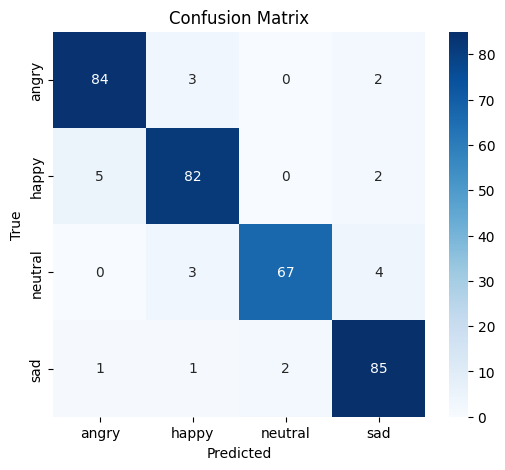


 Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.94      0.94        89
       happy       0.92      0.92      0.92        89
     neutral       0.97      0.91      0.94        74
         sad       0.91      0.96      0.93        89

    accuracy                           0.93       341
   macro avg       0.93      0.93      0.93       341
weighted avg       0.93      0.93      0.93       341



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 테스트셋 예측
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

# 2. Confusion Matrix 계산
cm = confusion_matrix(y_true, y_pred)

# 3. 클래스 라벨 정의 
emotion_labels = ['angry', 'happy', 'neutral', 'sad']

# 4. Confusion Matrix 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 5. Classification Report 출력
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))



## 9. Saving the Scaler for Future Inference (스케일러 저장)


This section saves the **StandardScaler** used for feature normalization, allowing consistent preprocessing during future inference or deployment.  
By saving the trained scaler, new input audio can be standardized in the same way as the training data.

Steps:
- Fit `StandardScaler` on the extracted MFCC features (`speech_data`)  
- Apply scaling using `fit_transform()`  
- Save the fitted scaler object using `joblib.dump()` to a file named `'scaler.save'`  
- The file can later be reloaded with `joblib.load('scaler.save')` before inference  

---  
이 섹션에서는 학습 시 사용한 **StandardScaler**를 저장하여, 추후 추론(inference) 단계에서도 동일한 방식으로 오디오 데이터를 정규화할 수 있도록 합니다.  
이를 통해 학습 데이터와 실시간 입력 데이터 간의 정규화 일관성을 유지합니다.

단계:
- 추출된 MFCC 특징(`speech_data`)에 대해 `StandardScaler`를 학습시킵니다 (`fit_transform()`)  
- 학습된 스케일러 객체를 `joblib.dump()`를 통해 `'scaler.save'` 파일로 저장합니다  
- 추후 추론 시 `joblib.load('scaler.save')`를 사용해 동일한 스케일러를 불러올 수 있습니다  

이 과정을 통해 모델 배포 시 데이터 전처리의 일관성을 유지할 수 있습니다.


In [19]:
import joblib

scaler = StandardScaler()
speech_data_scaled = scaler.fit_transform(speech_data)

joblib.dump(scaler, 'scaler.save')  # 현재 작업 디렉토리에 저장됨


['scaler.save']

## 10. Model Saving (모델 저장)

  
This step saves the **trained audio emotion recognition CNN model** in Keras format for future use, deployment, or conversion (e.g., to TensorFlow Lite or ONNX).  
By storing the `.keras` file, the model architecture, weights, and optimizer states are preserved.

Steps:
- Use `model.save("audio_emotion_model.keras")` to store the model  
- The saved file can later be reloaded using `keras.models.load_model("audio_emotion_model.keras")`  
- Ensures reproducibility and easy inference without retraining  

--- 
이 단계에서는 학습이 완료된 **음성 감정 인식 CNN 모델**을 Keras 형식으로 저장합니다.  
`.keras` 파일에는 모델의 구조, 가중치, 옵티마이저 상태가 모두 포함되어 있어 추후 재학습 없이 바로 추론에 사용할 수 있습니다.

단계:
- `model.save("audio_emotion_model.keras")` 명령어로 모델 저장  
- 나중에 `keras.models.load_model("audio_emotion_model.keras")`로 불러올 수 있습니다  
- 재현성과 배포 용이성을 보장하며, 실시간 감정 분석 시스템 등에 쉽게 통합할 수 있습니다.


In [20]:
# 모델 저장
model.save("audio_emotion_model.keras")
